<a href="https://colab.research.google.com/github/najahsadmim/adult-income-prediction/blob/main/CSE422_GRP04_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CSE422: ARTIFICIAL INTELLIGENCE**

##**PROJECT TOPIC**: ***Adult Income Prediction Using Machine Learning***

------------------------------------------------------


**SECTION 01 - GROUP 04**

**NAME               | ID**

Rayhan Jubayer Marib | 23201507

Najah Sadmim         | 24241014

-----------------------------------------------------



##**Import Libraries**

In [308]:
#import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import pointbiserialr

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

##**Retrieve and Display Dataset**

In [309]:
#load csv file

data = pd.read_csv('https://raw.githubusercontent.com/najahsadmim/adult-income-prediction/refs/heads/main/adult_income_dataset.csv')


## **Describe Dataset**

In [310]:
data.head(5)
data.shape

(48842, 15)

In [311]:
#show feature info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        48842 non-null  int64 
 1   Workclass                  48842 non-null  object
 2   Final Weight               48842 non-null  int64 
 3   Education                  48842 non-null  object
 4   Education Number of Years  48842 non-null  int64 
 5   Marital-status             48842 non-null  object
 6   Occupation                 48842 non-null  object
 7   Relationship               48842 non-null  object
 8   Race                       48842 non-null  object
 9   Sex                        48842 non-null  object
 10  Capital-gain               48842 non-null  int64 
 11  Capital-loss               48842 non-null  int64 
 12  Hours-per-week             48842 non-null  int64 
 13  Native-country             48842 non-null  object
 14  target

### **Data Types**

In [312]:
#Selecting numerical features

num_data = data.select_dtypes(include='number')

#Selecting categ features

categ_data = data.select_dtypes(include='object')

#append the features of num_data to list

num_features=num_data.columns.tolist()

#append the features of categ_data to list

categ_features=categ_data.columns.tolist()

#print list

print("No. of Numerical Features: ", len(num_features), "\n")
print("No. of Categorical Features: ", len(categ_features), "\n")
print(num_features)
print(categ_features)

No. of Numerical Features:  6 

No. of Categorical Features:  9 

['Age', 'Final Weight', 'Education Number of Years', 'Capital-gain', 'Capital-loss', 'Hours-per-week']
['Workclass', 'Education', 'Marital-status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native-country', 'target']


### **Numerical Data Analysis**

In [313]:
#feature info of data in num_data

num_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
Final Weight,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
Education Number of Years,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
Capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
Capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
Hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [314]:
#variance of data in num_data

num_data.var()

,0
Age,1.879781e+02
Final Weight,1.115221e+10
Education Number of Years,6.609901e+00
Capital-gain,5.553259e+07
Capital-loss,1.624127e+05
Hours-per-week,1.535479e+02


In [315]:
#skewness of data

num_data.skew()

,0
Age,0.557580
Final Weight,1.438892
Education Number of Years,-0.316525
Capital-gain,11.894659
Capital-loss,4.569809
Hours-per-week,0.238750


> **Plotting**

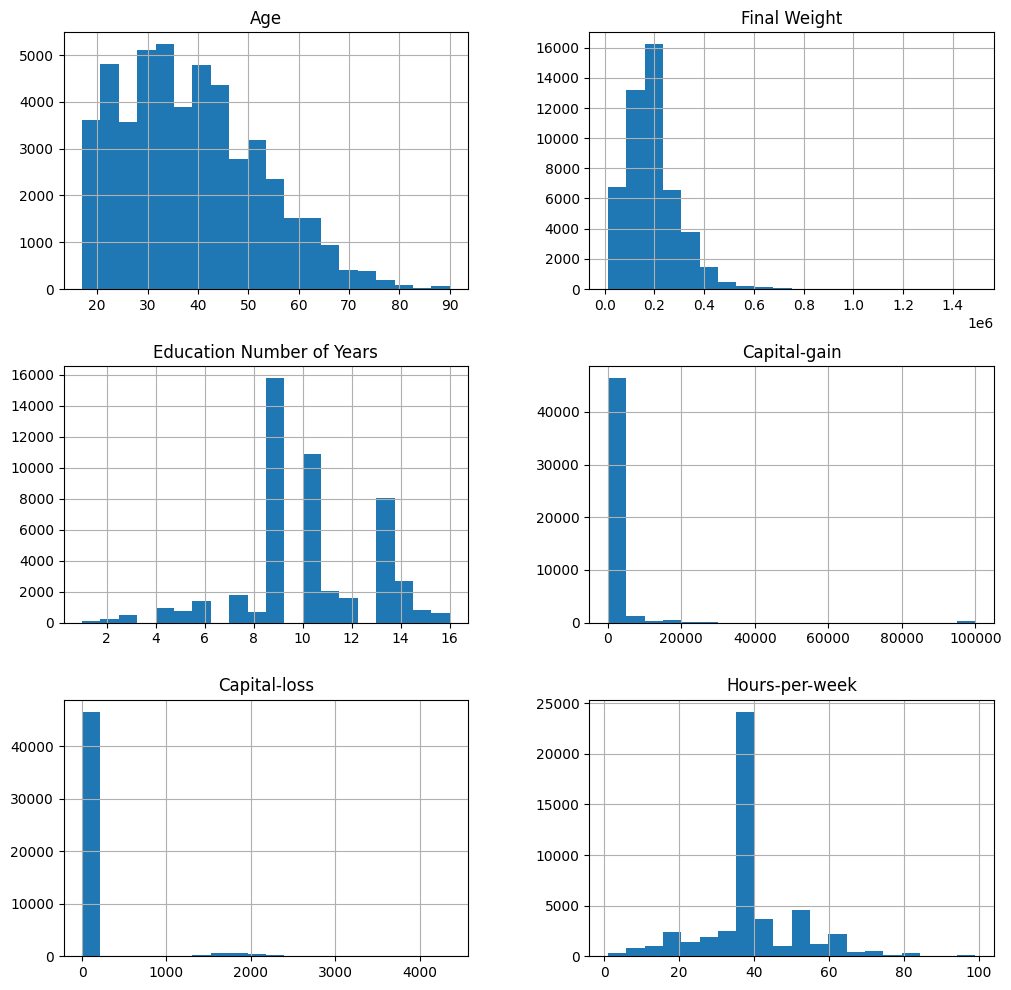

In [316]:
#show outliers on histogram

num_data.hist(figsize=(12,12),bins=20)
plt.show()

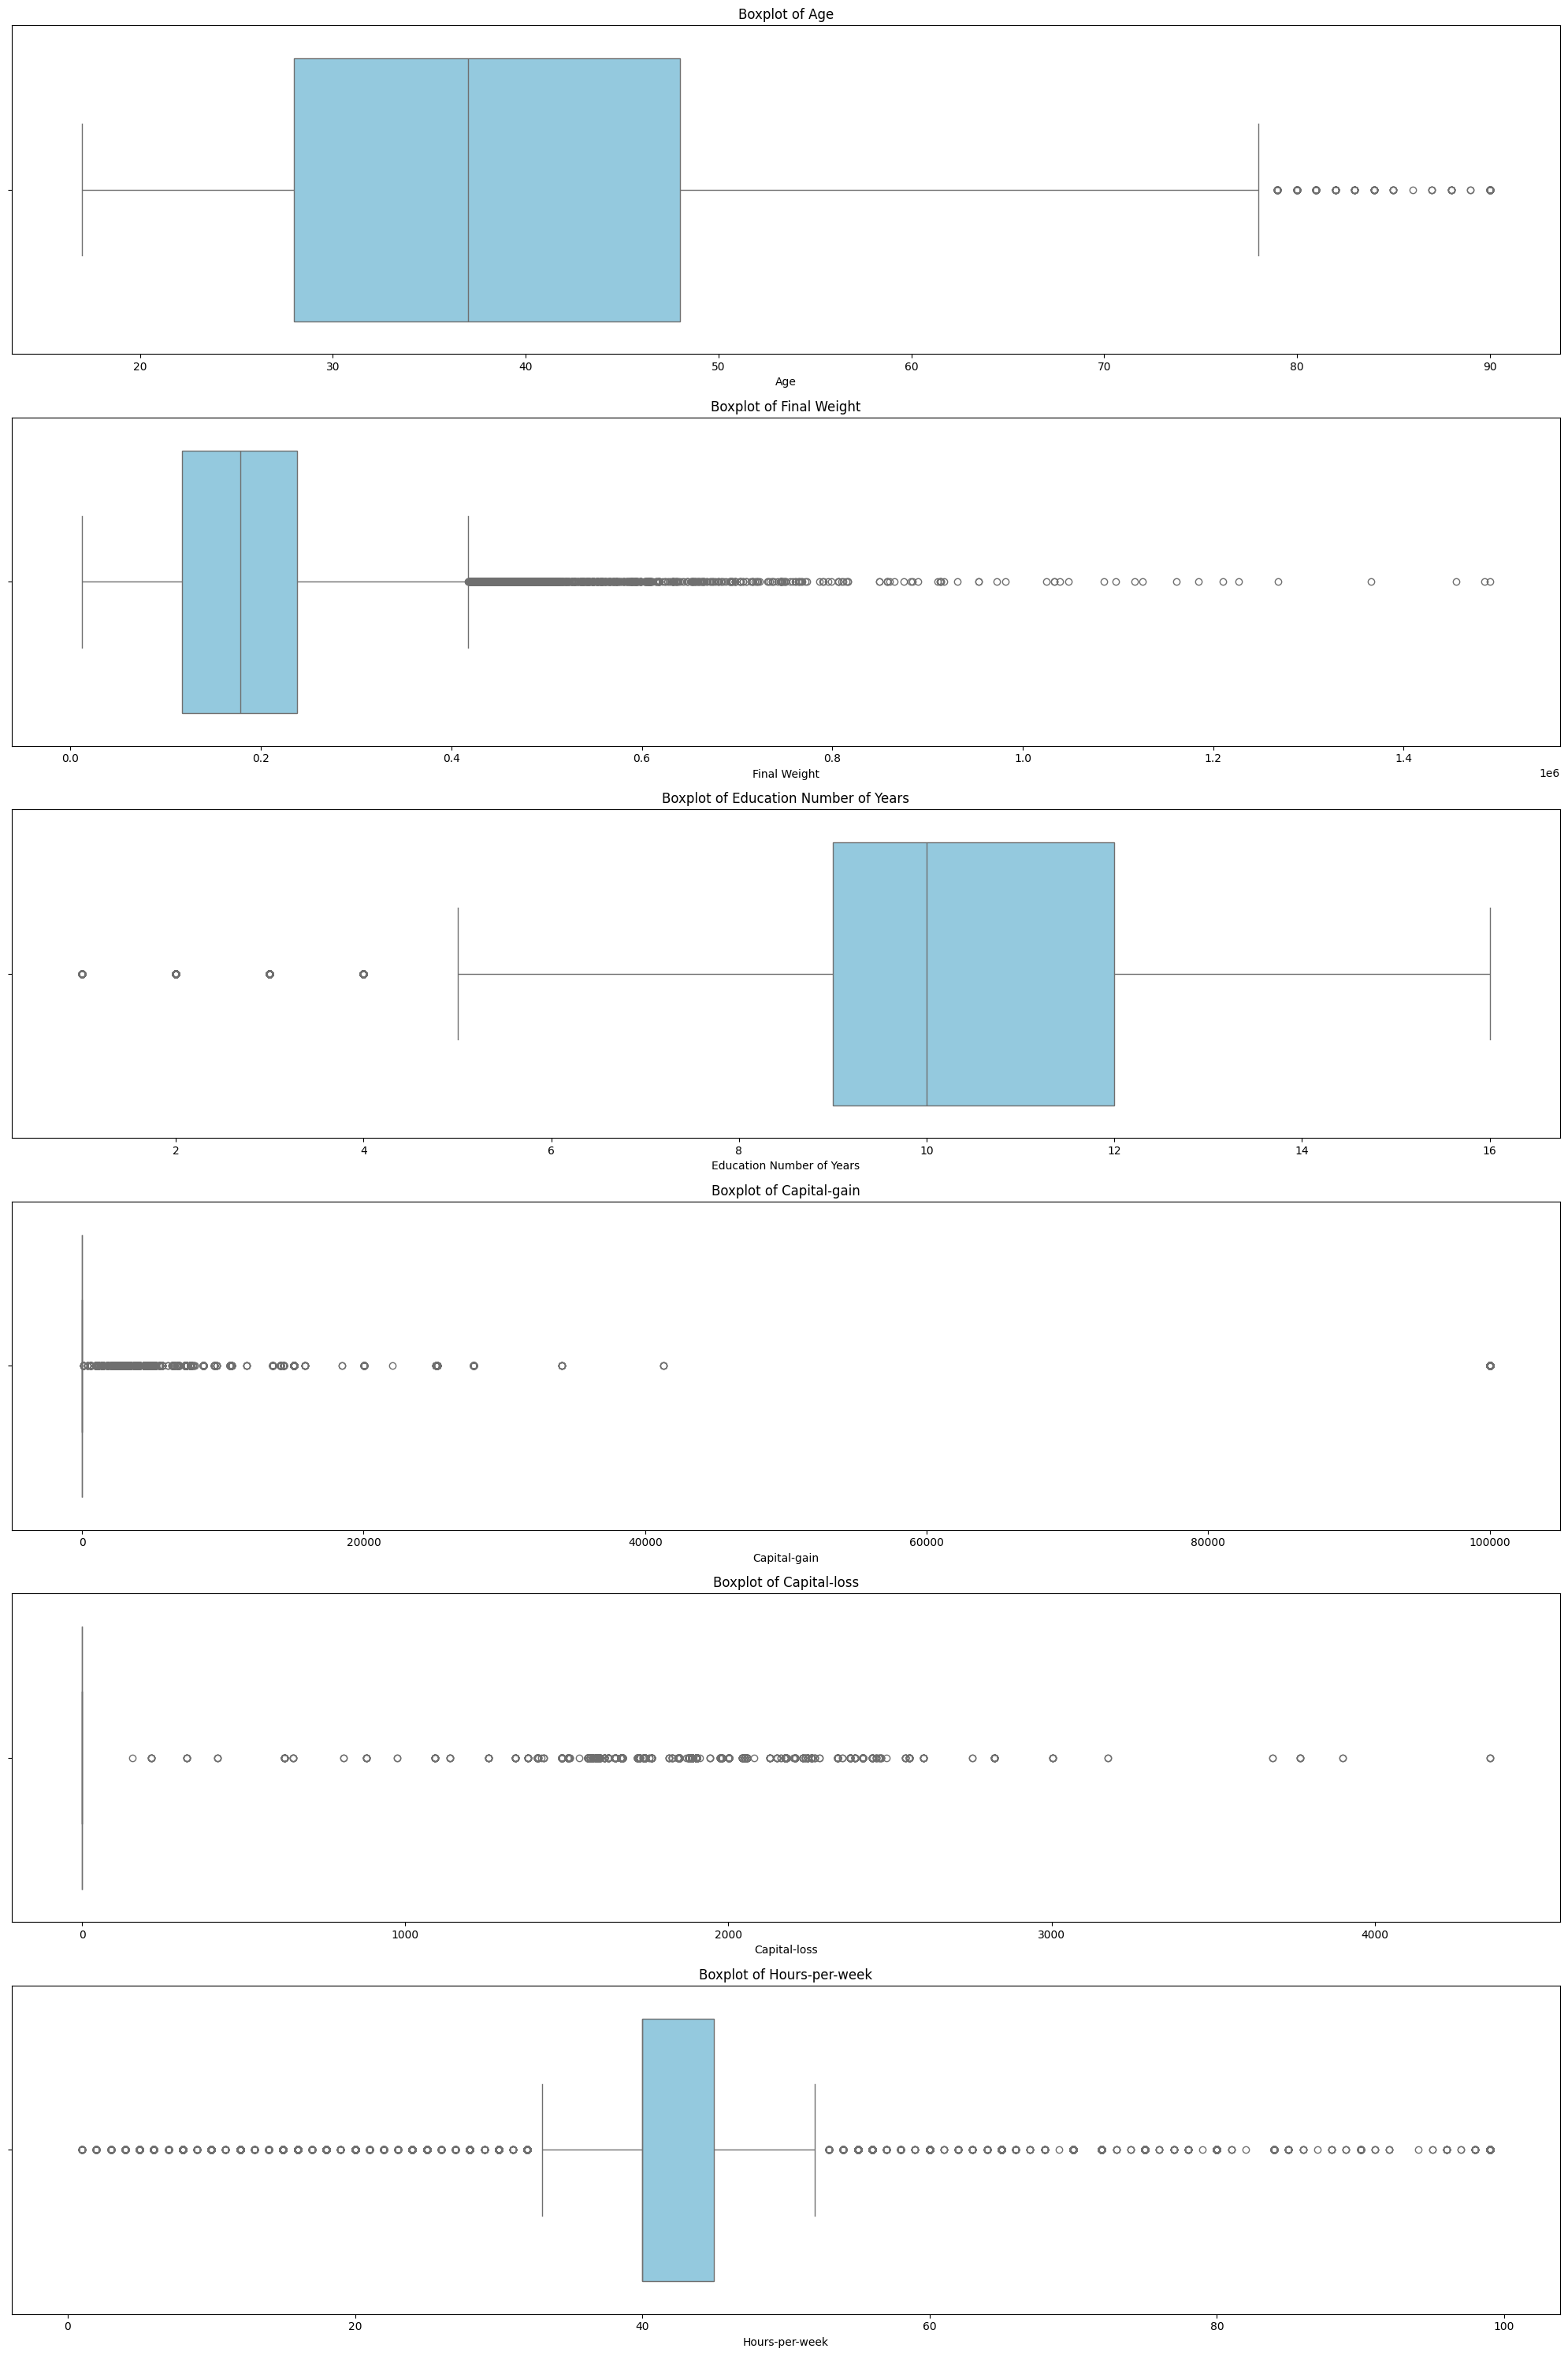

In [317]:
# Select only numerical columns for boxplot analysis

num_cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=data[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

> **Unique Values**

In [318]:
num_data.nunique()

,0
Age,74
Final Weight,28523
Education Number of Years,16
Capital-gain,123
Capital-loss,99
Hours-per-week,96


## **Categorical Features**

In [319]:
#unique values

categ_data.nunique()

,0
Workclass,9
Education,16
Marital-status,7
Occupation,15
Relationship,6
Race,5
Sex,2
Native-country,42
target,2


> **Plotting**

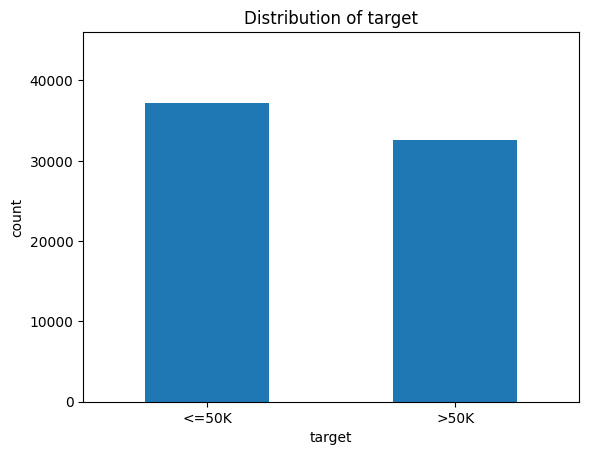

In [320]:
#plot bar char to represent each category

for col in categ_features:
    plt.title(f'Distribution of {col}')
    categ_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')

plt.show()

### **Correlation Analysis**

> **Correlation Matrix**

In [321]:
correlation_matrix = num_data.corr()
correlation_matrix

,Age,Final Weight,Education Number of Years,Capital-gain,Capital-loss,Hours-per-week
Age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
Final Weight,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
Education Number of Years,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
Capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
Capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
Hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


> **Correlation Heat Map**

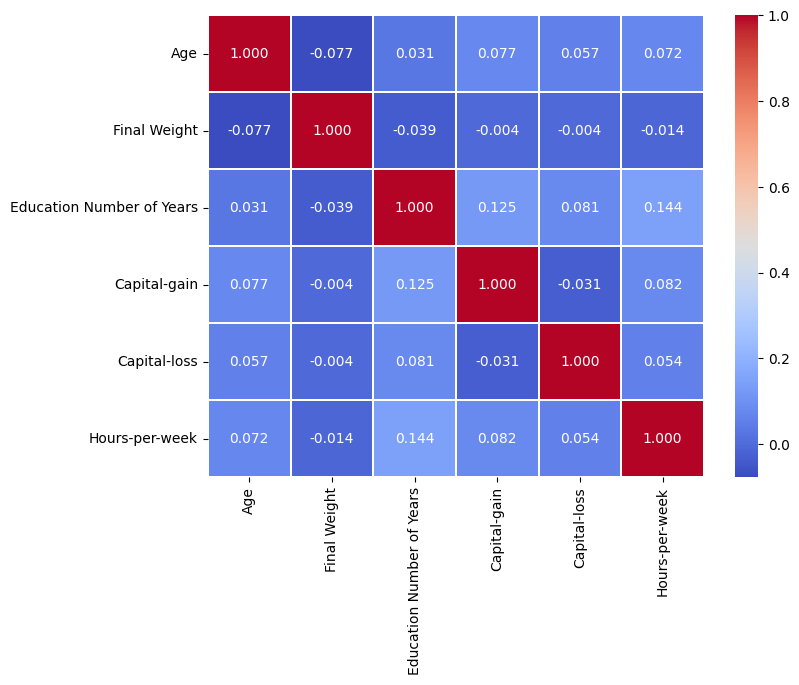

In [322]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

> **Correlation between numerical features and target**

In [323]:
data["target_binary"] = data["target"].map({
    "<=50K": 0,
    ">50K": 1
})

In [324]:
result= {}

for col in num_features:
  result[col]= pointbiserialr(data["target_binary"], data[col]).statistic

result

{'Age': np.float64(0.2303694678475206),
 'Final Weight': np.float64(-0.006338859530113219),
 'Education Number of Years': np.float64(0.3326131306661462),
 'Capital-gain': np.float64(0.22301302085823554),
 'Capital-loss': np.float64(0.14755448819939188),
 'Hours-per-week': np.float64(0.2276867605608139)}

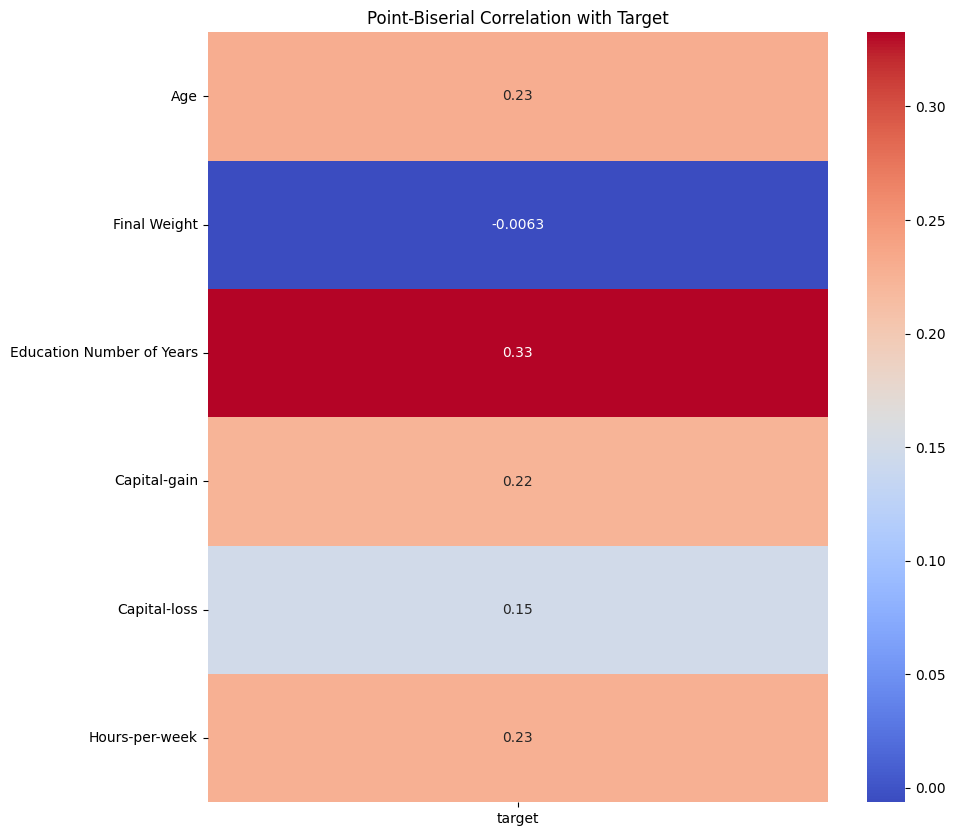

In [325]:
#plotting the heatmap

fig, ax = plt.subplots(figsize=(10, 10))

corr = pd.DataFrame.from_dict(result, orient="index", columns=["target"])

ax.set_title('Point-biserial method')

sns.heatmap(corr, ax=ax, annot=True, cmap="coolwarm")

plt.title("Point-Biserial Correlation with Target")
plt.show()

> **Education No. of Years - Target Relationship Analysis**

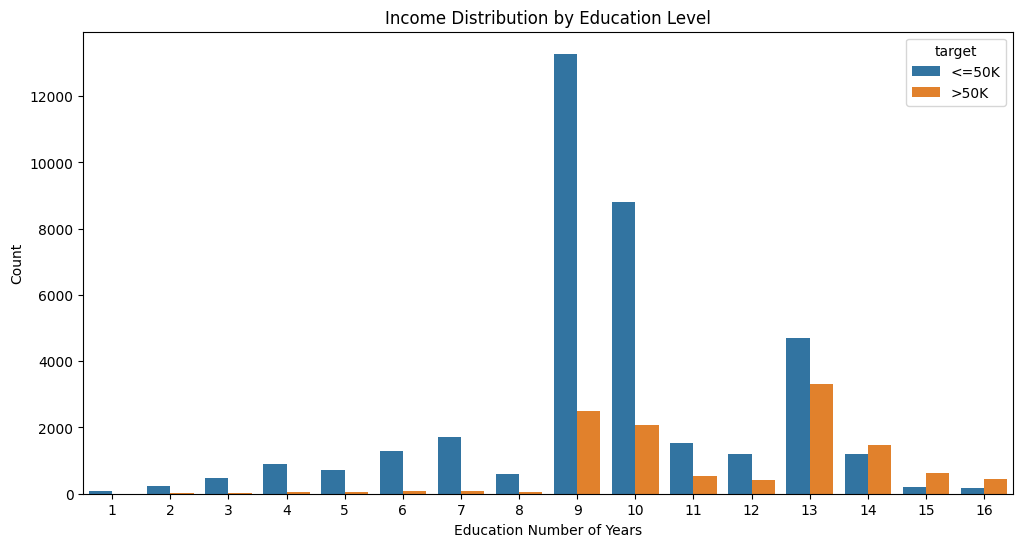

In [326]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="Education Number of Years",
    hue="target"
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education Number of Years")
plt.ylabel("Count")

plt.show()

###**Check Class Imbalance**

In [327]:
#check Imbalance in data

class_counts=data.groupby("target").size()

columns=['target','count','percentage']
target=["<=50K",">50K"]
count=list()
percentage=list()

#Calculate the percentage of each value of the 'target' variable from total

for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/len(data))*100
    percentage.append(percent)

# Convert the calulated values into a dataframe

imbalance_df=pd.DataFrame(list(zip(target,count,percentage)),columns=columns)
imbalance_df

/tmp/ipykernel_1056/238078980.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count.append(class_counts[val])
/tmp/ipykernel_1056/238078980.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percent=(class_counts[val]/len(data))*100


,target,count,percentage
0,<=50K,37155,76.071823
1,>50K,11687,23.928177


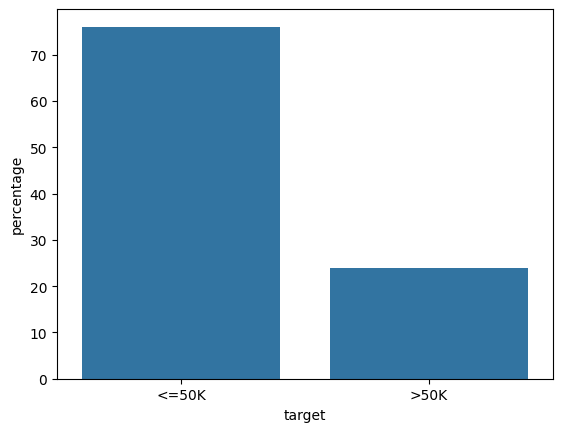

In [328]:
#plot class imbalance on barchart

sns.barplot(data=imbalance_df,x=imbalance_df['target'],y=imbalance_df['percentage'])
plt.show()

##**Handle Null and Duplicate Values**

###**Dropping Duplicates**

In [329]:
#count number of duplicates rows/records

data.duplicated().sum()

np.int64(52)

In [330]:
#drop duplicate rows

data=data.drop_duplicates()

###**Data Imputation**



In [331]:
#show count of '?'

(data=='?').sum()

,0
Age,0
Workclass,2795
Final Weight,0
Education,0
Education Number of Years,0
Marital-status,0
Occupation,2805
Relationship,0
Race,0
Sex,0


In [332]:
#replace '?' values with null values

data.replace("?", np.nan, inplace=True)

#count number of null values

data.isnull().sum()

,0
Age,0
Workclass,2795
Final Weight,0
Education,0
Education Number of Years,0
Marital-status,0
Occupation,2805
Relationship,0
Race,0
Sex,0


## **Feature Selection**

In [333]:
# Feature Selection

# Drop features that we decided not to use
# Education is redundant with Education Number of Years
# Final Weight is not useful for our prediction objective

data_model = data.drop(
    columns=["Education", "Final Weight", "target_binary"]
)

print("Dataset shape:", data_model.shape)
print("\nFeatures:")
print(data_model.columns.tolist())

# Separate input features and target
X = data_model.drop("target", axis=1)

# Convert target into binary values
y = data_model["target"].map({
    "<=50K": 0,
    ">50K": 1
})

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

Dataset shape: (48790, 13)

Features:
['Age', 'Workclass', 'Education Number of Years', 'Marital-status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital-gain', 'Capital-loss', 'Hours-per-week', 'Native-country', 'target']

X shape: (48790, 12)
y shape: (48790,)

First 5 rows of X:


,Age,Workclass,Education Number of Years,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba



First 5 target values:


,target
0,0
1,0
2,0
3,0
4,0


## **Feature Types**

In [334]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(include='number').columns.tolist()

categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical Features:
['Age', 'Education Number of Years', 'Capital-gain', 'Capital-loss', 'Hours-per-week']

Categorical Features:
['Workclass', 'Marital-status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native-country']

Number of numerical features: 5
Number of categorical features: 7


## **Training and Testing Data**

> **Split Dataset**

In [335]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

> **Fit Training Data**

In [336]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


> **Transform Data**

In [337]:
#X_train
X_train_processed = preprocessor.fit_transform(X_train)
print("Processed training shape:", X_train_processed.shape)

Processed training shape: (39032, 88)


In [338]:
#X_test
X_test_processed = preprocessor.transform(X_test)
preprocessor.transform(X_test)

array([[ 0.10226472, -0.41999538, -0.1441952 , ...,  1.        ,
         0.        ,  0.        ],
       [ 3.31552246, -0.41999538, -0.1441952 , ...,  1.        ,
         0.        ,  0.        ],
       [ 2.36615085, -0.41999538, -0.1441952 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.26287821,  0.74833689, -0.1441952 , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.97860774, -2.36721583, -0.1441952 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.18984962, -0.03055129,  0.55465031, ...,  1.        ,
         0.        ,  0.        ]])

## **Supervised Model Training**

### **Neural Networks**

> **Train, Test, Predict**

In [339]:
### Neural Network

# Create the Neural Network model
# Following the structure demonstrated in the Neural Network lab:
# Dense layers with ReLU activation and an output layer.

neural_network = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model using Adam optimizer
neural_network.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
neural_network.summary()

# Train the Neural Network

nn_history = neural_network.fit(
    X_train_processed,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.10,
    verbose=1
)
# Predict probabilities on the test set

nn_pred_prob = neural_network.predict(
    X_test_processed,
    verbose=0
).ravel()

# Convert probabilities into binary predictions
nn_pred = (nn_pred_prob >= 0.5).astype(int)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 128)            │        11,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,713 (77.00 KB)

 Trainable params: 19,713 (77.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8372 - loss: 0.3449 - val_accuracy: 0.8594 - val_loss: 0.3079
Epoch 2/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8551 - loss: 0.3121 - val_accuracy: 0.8635 - val_loss: 0.3030
Epoch 3/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8558 - loss: 0.3079 - val_accuracy: 0.8609 - val_loss: 0.3018
Epoch 4/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8580 - loss: 0.3047 - val_accuracy: 0.8617 - val_loss: 0.3006
Epoch 5/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8593 - loss: 0.3027 - val_accuracy: 0.8642 - val_loss: 0.2996
Epoch 6/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8608 - loss: 0.3005 - val_accuracy: 0.8632 - val_loss: 0.3014
Epoch 7/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8618 - loss: 0.2984 - val_accuracy: 0.8624 - val_loss: 0.3004
Epoch 8/10
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8632 - loss: 0.2955 - val_accuracy: 0.

> **Check Model Performance**

In [340]:
nn_accuracy = accuracy_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred)
nn_recall = recall_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)

print("Neural Network Performance")
print("--------------------------")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1 Score:  {nn_f1:.4f}")

Neural Network Performance
--------------------------
Accuracy:  0.8579
Precision: 0.7227
Recall:    0.6592
F1 Score:  0.6895


> **Confusion Matrix**

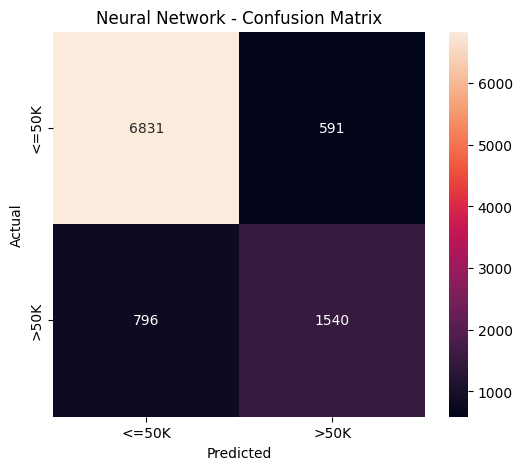

In [341]:
#...# Confusion Matrix

nn_cm = confusion_matrix(y_test, nn_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    nn_cm,
    annot=True,
    fmt='d',
    xticklabels=['<=50K', '>50K'],
    yticklabels=['<=50K', '>50K']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network - Confusion Matrix')

plt.show()

### **Logistic Regression**

> **Train, Test, Predict**

In [342]:
#create model

logistic_model= LogisticRegression(max_iter=1000, random_state=42)

#train the model

logistic_model.fit(X_train_processed, y_train)

#predict on test set

lr_pred= logistic_model.predict(X_test_processed)

> **Check Model Performance**

In [343]:
print("Logistic Regression Performance Overview")
print("----------------------------------------")

print("\nAccuracy: ", accuracy_score(y_test, lr_pred))
print("\nPrecision: ", precision_score(y_test, lr_pred))
print("\nRecall: ", recall_score(y_test, lr_pred))
print("\nF1 Score: ", f1_score(y_test, lr_pred))

Logistic Regression Performance Overview
----------------------------------------

Accuracy:  0.8536585365853658

Precision:  0.7325819672131147

Recall:  0.6121575342465754

F1 Score:  0.6669776119402985


> **Confusion Matrix**

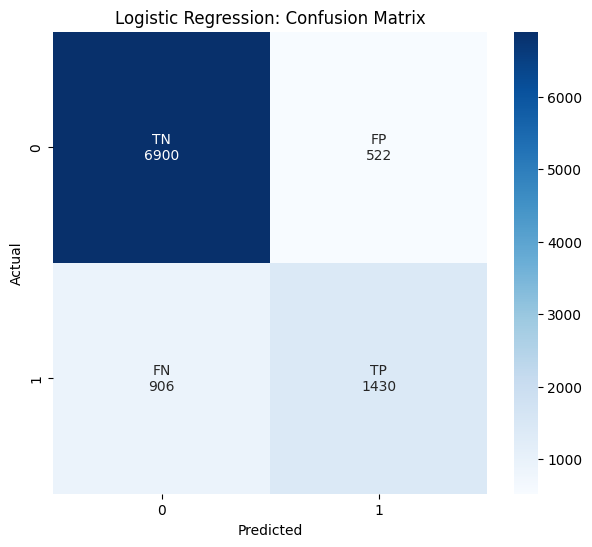

In [344]:
lr_cm= confusion_matrix(y_test, lr_pred)

labels= [
    [f"TN\n{lr_cm[0,0]}", f"FP\n{lr_cm[0,1]}"],
    [f"FN\n{lr_cm[1,0]}", f"TP\n{lr_cm[1,1]}"]
]

plt.figure(figsize=(7,6))
sns.heatmap(lr_cm, annot=labels, fmt="", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression: Confusion Matrix")

plt.show()

### **Decision Tree**

> **Train, Test, Predict**

In [345]:
#create model

dec_tree= DecisionTreeClassifier(random_state=42)

#train model

dec_tree.fit(X_train_processed, y_train)

#predict

dt_pred= dec_tree.predict(X_test_processed)

> **Check Model Performance**

In [346]:
print("Decision Tree Performance Overview")
print("----------------------------------------")

print("\nAccuracy: ", accuracy_score(y_test, dt_pred))
print("\nPrecision: ", precision_score(y_test, dt_pred))
print("\nRecall: ", recall_score(y_test, dt_pred))
print("\nF1 Score: ", f1_score(y_test, dt_pred))

Decision Tree Performance Overview
----------------------------------------

Accuracy:  0.8282434925189588

Precision:  0.6453744493392071

Recall:  0.6271404109589042

F1 Score:  0.6361267911419887


> **Confusion Matrix**

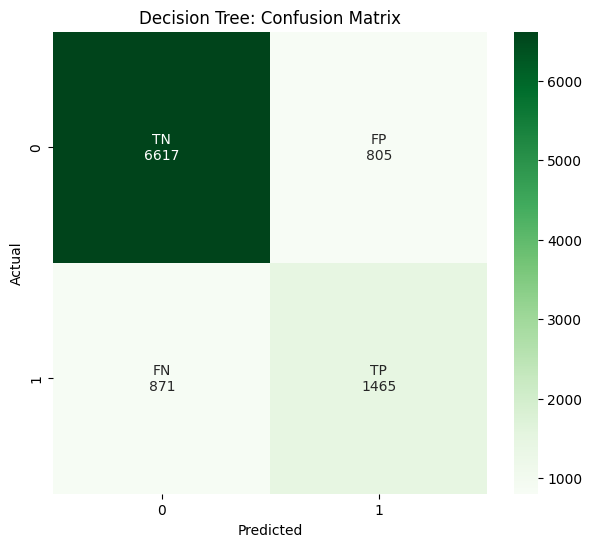

In [347]:
dt_cm= confusion_matrix(y_test, dt_pred)

labels= [
    [f"TN\n{dt_cm[0,0]}", f"FP\n{dt_cm[0,1]}"],
    [f"FN\n{dt_cm[1,0]}", f"TP\n{dt_cm[1,1]}"]
]

plt.figure(figsize=(7,6))
sns.heatmap(dt_cm, annot=labels, fmt="", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree: Confusion Matrix")

plt.show()

### **ROC Curve and AUC Score**

> **Logistic Regression**

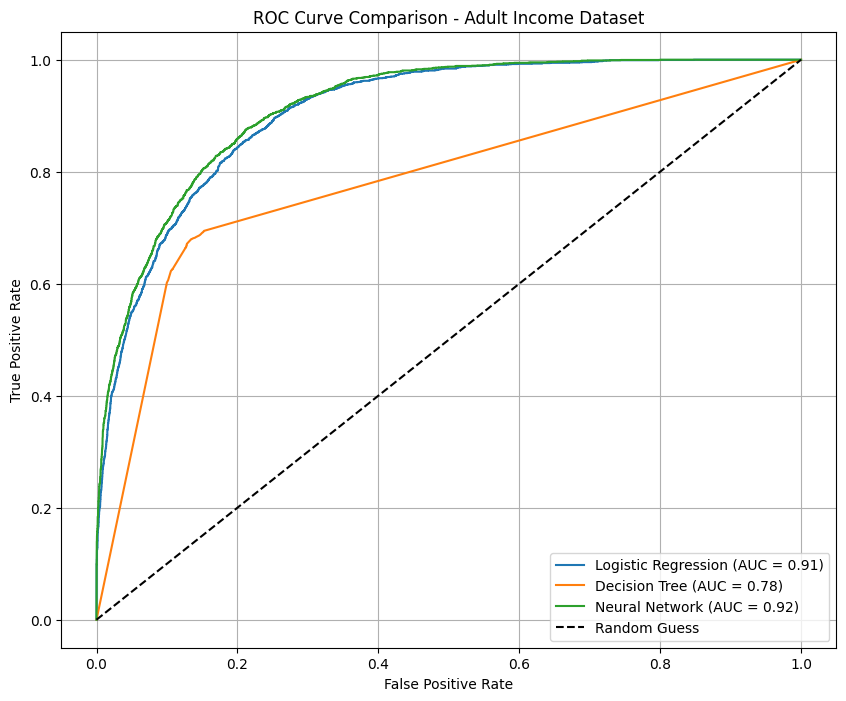

In [348]:
# LOGISTIC REGRESSION

plt.figure(figsize=(10, 8))

lr_probs = logistic_model.predict_proba(X_test_processed)[:, 1]

# ROC and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")

#DECISION TREE

dt_probs = dec_tree.predict_proba(X_test_processed)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")

#NEURAL NETWORK

nn_probs = neural_network.predict(X_test_processed, verbose=0).ravel()

fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {roc_auc_nn:.2f})")


# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Adult Income Dataset")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### **K-Fold Cross Validation**

In [349]:
cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y):
  scores= cross_val_score(model, X, y, cv=cv, scoring='accuracy')

  print("Fold scores:\n", scores)
  print("Mean CV Accuracy:\n", scores.mean())

> **Evaluate Neural Network**

In [350]:
#create fresh copy of model

def create_nn():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

#define stratified cross val

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

nn_accuracies=[]

#perform k-fold cv

for fold, (train_index, val_index) in enumerate(kf.split(X_train_processed, y_train), start=1):
  X_fold_train=X_train_processed[train_index]
  X_fold_val=X_train_processed[val_index]

  y_fold_train= y_train.iloc[train_index]
  y_fold_val= y_train.iloc[val_index]

  #create copy of model for this fold

  model= create_nn()

  #train

  model.fit(X_fold_train, y_fold_train, epochs=10, batch_size=128, verbose=0)

  #evaluate

  _, accuracy= model.evaluate(X_fold_val, y_fold_val, verbose=0)
  nn_accuracies.append(accuracy)

  print(f"Fold {fold} Accuracy: {accuracy:.4f}")

#avg accuracy
avg_nn_acc= np.mean(nn_accuracies)

print("\nNeural Network")
print("----------------")
print("Fold Scores:", [round(score, 4) for score in nn_accuracies])
print(f"Mean CV Accuracy: {avg_nn_acc:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy: 0.8547
Fold 2 Accuracy: 0.8509
Fold 3 Accuracy: 0.8549
Fold 4 Accuracy: 0.8522
Fold 5 Accuracy: 0.8631

Neural Network
----------------
Fold Scores: [0.8547, 0.8509, 0.8549, 0.8522, 0.8631]
Mean CV Accuracy: 0.8551


>**Evaluate Logistic Regression**

In [351]:
print("Logistic Regression")
print("-------------------")
evaluate_model(logistic_model, X_train_processed, y_train)

Logistic Regression
-------------------
Fold scores:
 [0.8487255  0.84706033 0.85088394 0.84499103 0.85959518]
Mean CV Accuracy:
 0.8502511968784724


>**Evaluate Decision Tree**

In [352]:
print("Decision Tree")
print("-------------------")
evaluate_model(dec_tree, X_train_processed, y_train)

Decision Tree
-------------------
Fold scores:
 [0.81683105 0.81260407 0.80976172 0.82001025 0.82346913]
Mean CV Accuracy:
 0.8165352437836966


### **Compare Models**

> **Compare Model Scores**

In [353]:
#create dataframe table to display all scores of all supervised models together

compar= pd.DataFrame({
    "Model": ["Neural Network", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, nn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, nn_pred),
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, nn_pred),
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nn_pred),
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred)
    ],
    "AUC": [
        roc_auc_score(y_test, nn_probs),
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, dt_probs)
    ]

})

compar

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Neural Network,0.857860,0.722665,0.659247,0.689501,0.915716
1,Logistic Regression,0.853659,0.732582,0.612158,0.666978,0.907558
2,Decision Tree,0.828243,0.645374,0.627140,0.636127,0.782694


> **Best Model Based on Each Score**

In [354]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

best_model= pd.DataFrame({
    "Metric": metrics,
    "Best Model": [
        compar.loc[compar[metric].idxmax(), "Model"]
        for metric in metrics
    ],

    "Score": [
        compar.loc[compar[metric].idxmax(), metric]
        for metric in metrics
    ]
})

best_model.round(2)

,Metric,Best Model,Score
0,Accuracy,Neural Network,0.86
1,Precision,Logistic Regression,0.73
2,Recall,Neural Network,0.66
3,F1 Score,Neural Network,0.69


## **Unsupervised Model Training**

### **K-Clustering**

> **Data Preparation and Optimal K**

In [355]:
#...

>**K-Means and Distribution**

In [356]:
#...

> **Visualize Clusters**

In [357]:
#...